In [1]:
from warnings import filterwarnings
filterwarnings("ignore")

# Step 1 - Data Ingestion

In [2]:
import pandas as pd
df = pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

# Step 2 - Perfom basic data quality check

In [4]:
df.shape

(150, 5)

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)
df.shape

(149, 5)

In [7]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


# Step 3 - Apply Preprocessing on X

In [9]:
X = df.drop(columns = ["species"])
Y = df["species"]

In [10]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
Y.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

# Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.33, random_state=21)

In [13]:
xtrain.shape

(99, 4)

In [14]:
xtest.shape

(50, 4)

In [15]:
xtrain.head()

,sepal_length,sepal_width,petal_length,petal_width
52,6.9,3.1,4.9,1.5
49,5.0,3.3,1.4,0.2
65,6.7,3.1,4.4,1.4
117,7.7,3.8,6.7,2.2
55,5.7,2.8,4.5,1.3


In [16]:
ytrain.head()

52     versicolor
49         setosa
65     versicolor
117     virginica
55     versicolor
Name: species, dtype: object

In [17]:
xtest.head()

,sepal_length,sepal_width,petal_length,petal_width
92,5.8,2.6,4.0,1.2
44,5.1,3.8,1.9,0.4
7,5.0,3.4,1.5,0.2
21,5.1,3.7,1.5,0.4
95,5.7,3.0,4.2,1.2


In [18]:
ytest.head()

92    versicolor
44        setosa
7         setosa
21        setosa
95    versicolor
Name: species, dtype: object

# Apply preprocessing on X

In [19]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [20]:
X.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [22]:
num_pipe = make_pipeline(
    SimpleImputer(strategy = "median"),
    StandardScaler()
).set_output(transform = "pandas")

In [23]:
num_pipe.fit(xtrain)

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [24]:
xtrain_pre = num_pipe.transform(xtrain)
xtrain_pre.head()

,sepal_length,sepal_width,petal_length,petal_width
52,1.228059,0.047378,0.616798,0.356416
49,-1.032194,0.516425,-1.354794,-1.323832
65,0.990137,0.047378,0.335142,0.227166
117,2.179744,1.689042,1.630760,1.261165
55,-0.199469,-0.656192,0.391473,0.097917


In [25]:
xtest_pre = num_pipe.transform(xtest)
xtest_pre.head()

,sepal_length,sepal_width,petal_length,petal_width
92,-0.080509,-1.125239,0.109817,-0.031333
44,-0.913233,1.689042,-1.073138,-1.065332
7,-1.032194,0.750949,-1.298463,-1.323832
21,-0.913233,1.454519,-1.298463,-1.065332
95,-0.199469,-0.187145,0.222480,-0.031333


# Build Logistic Regression model

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(xtrain_pre, ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
model.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [28]:
model.intercept_

array([-0.26149001,  1.71213252, -1.45064251])

In [29]:
model.coef_

array([[-0.92887027,  1.21167588, -1.61658221, -1.59342784],
       [ 0.43257782, -0.43916224, -0.21402588, -0.77312914],
       [ 0.49629244, -0.77251364,  1.83060809,  2.36655698]])

# Evalutate Model object

In [30]:
model.score(xtrain_pre, ytrain)

0.9797979797979798

In [31]:
model.score(xtest_pre, ytest)

0.94

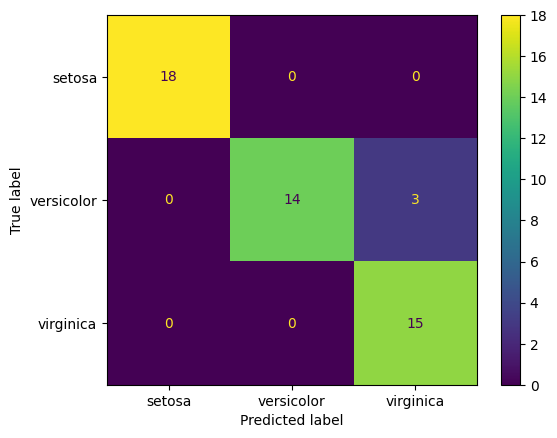

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, xtest_pre, ytest)

In [33]:
from sklearn.metrics import classification_report

ypred_test = model.predict(xtest_pre)
print(classification_report(ytest, ypred_test))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       1.00      0.82      0.90        17
   virginica       0.83      1.00      0.91        15

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.95      0.94      0.94        50



# From above results i can say that the f1 score >= 0.8

# Perform out of sample prediction

In [34]:
xnew = pd.read_csv("iris_sample.csv")
xnew

,sepal_length,sepal_width,petal_length,petal_width
0,5.5,2.5,4.0,1.3
1,6.9,3.1,5.1,2.3
2,5.1,2.5,3.0,1.1
3,4.4,2.9,NaN,0.2
4,5.9,3.0,5.1,1.8
5,5.5,3.5,1.3,0.2
6,5.6,NaN,3.6,1.3
7,6.5,3.0,5.2,2.0
8,5.3,3.7,1.5,0.2
9,5.1,3.4,1.5,NaN


In [35]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [36]:
xnew_pre = num_pipe.transform(xnew)
xnew_pre

,sepal_length,sepal_width,petal_length,petal_width
0,-0.437391,-1.359762,0.109817,0.097917
1,1.228059,0.047378,0.729461,1.390415
2,-0.913233,-1.359762,-0.453495,-0.160583
3,-1.745958,-0.421668,0.335142,-1.323832
4,0.038452,-0.187145,0.729461,0.744166
5,-0.437391,0.985472,-1.411125,-1.323832
6,-0.318430,-0.187145,-0.115507,0.097917
7,0.752216,-0.187145,0.785792,1.002666
8,-0.675312,1.454519,-1.298463,-1.323832
9,-0.913233,0.750949,-1.298463,0.097917


In [37]:
preds = model.predict(xnew_pre)
preds

array(['versicolor', 'virginica', 'versicolor', 'setosa', 'virginica',
       'setosa', 'versicolor', 'virginica', 'setosa', 'setosa',
       'versicolor', 'versicolor', 'virginica', 'versicolor', 'virginica'],
      dtype=object)

In [38]:
model.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [39]:
probs = model.predict_proba(xnew_pre)
probs

array([[1.86739252e-02, 8.83913243e-01, 9.74128319e-02],
       [1.93661222e-04, 5.97020754e-02, 9.40104263e-01],
       [9.77772503e-02, 8.88881379e-01, 1.33413704e-02],
       [5.79770423e-01, 4.19661319e-01, 5.68257776e-04],
       [6.10945608e-03, 3.23210738e-01, 6.70679806e-01],
       [9.64899594e-01, 3.50994970e-02, 9.09499510e-07],
       [1.40196894e-01, 8.20903512e-01, 3.88995946e-02],
       [8.23632462e-04, 1.54044752e-01, 8.45131615e-01],
       [9.85992175e-01, 1.40074400e-02, 3.84957586e-07],
       [9.04414902e-01, 9.53019243e-02, 2.83173717e-04],
       [2.28698410e-02, 8.95445856e-01, 8.16843030e-02],
       [2.38005395e-02, 9.52419547e-01, 2.37799135e-02],
       [4.69764301e-06, 1.71710436e-02, 9.82824259e-01],
       [5.93255838e-03, 6.68652095e-01, 3.25415347e-01],
       [5.31595677e-04, 4.92136889e-01, 5.07331515e-01]])

In [40]:
xnew["species"] = preds
xnew[model.classes_] = probs.round(4)

In [41]:
xnew

,sepal_length,sepal_width,petal_length,petal_width,species,setosa,versicolor,virginica
0,5.5,2.5,4.0,1.3,versicolor,0.0187,0.8839,0.0974
1,6.9,3.1,5.1,2.3,virginica,0.0002,0.0597,0.9401
2,5.1,2.5,3.0,1.1,versicolor,0.0978,0.8889,0.0133
3,4.4,2.9,NaN,0.2,setosa,0.5798,0.4197,0.0006
4,5.9,3.0,5.1,1.8,virginica,0.0061,0.3232,0.6707
5,5.5,3.5,1.3,0.2,setosa,0.9649,0.0351,0.0000
6,5.6,NaN,3.6,1.3,versicolor,0.1402,0.8209,0.0389
7,6.5,3.0,5.2,2.0,virginica,0.0008,0.1540,0.8451
8,5.3,3.7,1.5,0.2,setosa,0.9860,0.0140,0.0000
9,5.1,3.4,1.5,NaN,setosa,0.9044,0.0953,0.0003


In [42]:
xnew.to_csv("results.csv", index=False)

# Save the preprocessor and model

In [43]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [44]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
import joblib

joblib.dump(num_pipe, "pre.joblib")

['pre.joblib']

In [46]:
joblib.dump(model, "iris_model.joblib")

['iris_model.joblib']

# Load the model object

In [47]:
p = joblib.load("pre.joblib")
p

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [48]:
m = joblib.load("iris_model.joblib")
m

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [49]:
m.score(xtrain_pre, ytrain)

0.9797979797979798

In [50]:
m.score(xtest_pre, ytest)

0.94